In [112]:
import joblib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, precision_recall_curve


from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor

In [113]:
def show_precision_recall_curve(y_true, y_proba, punto_corte=0.5):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)

    plt.plot(thr, rec[:-1], label='recall')
    plt.plot(thr, prec[:-1], label='precision')
    plt.xlabel('Punto de corte')
    plt.vlines(punto_corte, 0, 1, colors='red', linestyles='dashed', label='corte')
    plt.legend()
    plt.show()

def show_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Matriz de Confusión');

In [114]:
path = './audios_propios/ciclos_energy_based'
files = os.listdir(path)

In [115]:
paths = [os.path.join(path, f) for f in files]

In [116]:
pipeline_melspec = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('padder', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

pipeline_features = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor())
])

In [117]:
X_propios_melspec = pipeline_melspec.fit_transform(paths)

In [118]:
X_propios_features = pipeline_features.fit_transform(paths)

## ciclos_f2_r

### melspec_rf

In [119]:
test_data = np.load(f'./dataset/ciclos_f2_r/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [120]:
melspec_rf = joblib.load('./modelos/ciclos_f2_r/melspec_rf.pkl')

In [121]:
y_pred = melspec_rf.predict(X_test)
y_pred_proba = melspec_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.88      0.82       180
           1       0.86      0.73      0.79       179

    accuracy                           0.80       359
   macro avg       0.81      0.80      0.80       359
weighted avg       0.81      0.80      0.80       359



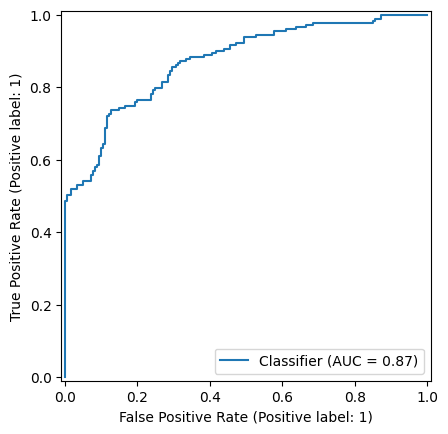

In [122]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

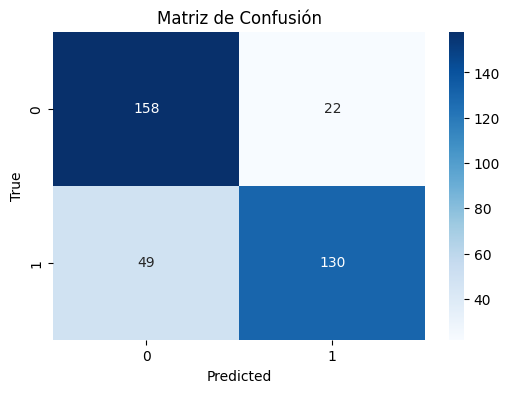

In [123]:
show_confusion_matrix(y_test, y_pred)

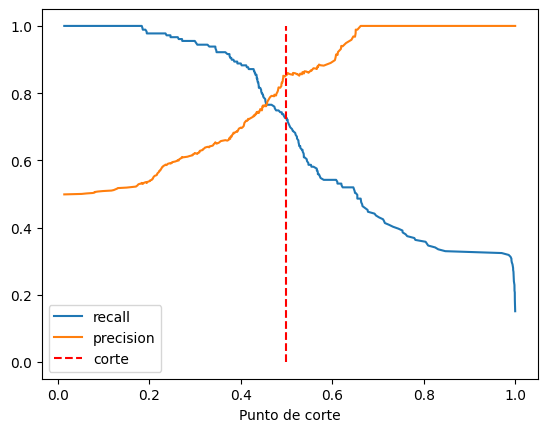

In [124]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

In [125]:
probas_propios = melspec_rf.predict_proba(X_propios_melspec)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.463438
1,respiracion1_ciclo_2.wav,0.958081
2,respiracion1_ciclo_3.wav,0.607865
3,respiracion1_ciclo_4.wav,0.994619
4,respiracion1_ciclo_5.wav,0.952282
5,respiracion1_ciclo_6.wav,0.429511
6,respiracion1_ciclo_7.wav,0.528697
7,respiracion2_ciclo_1.wav,0.987918
8,respiracion2_ciclo_2.wav,0.621276
9,respiracion2_ciclo_3.wav,0.508670


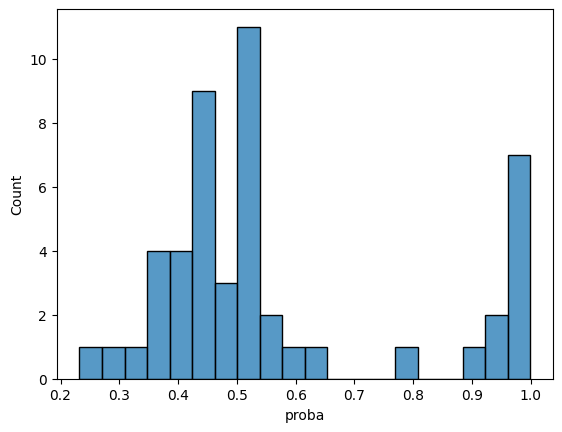

In [126]:
sns.histplot(df_probas, x='proba', bins=20);

### features_rf

In [127]:
test_data = np.load(f'./dataset/ciclos_f2_r/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [128]:
feat_rf = joblib.load('./modelos/ciclos_f2_r/features_rf.pkl')

In [129]:
y_pred = feat_rf.predict(X_test)
y_pred_proba = feat_rf.predict_proba(X_test)[:, 1]

In [130]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       180
           1       0.89      0.79      0.83       179

    accuracy                           0.84       359
   macro avg       0.85      0.84      0.84       359
weighted avg       0.85      0.84      0.84       359



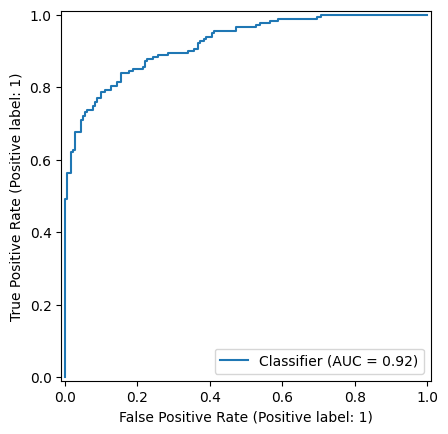

In [131]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

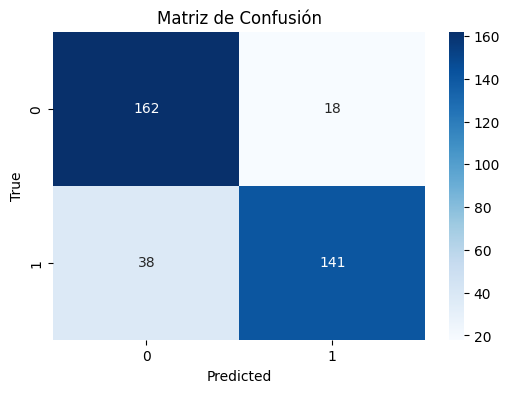

In [132]:
show_confusion_matrix(y_test, y_pred)

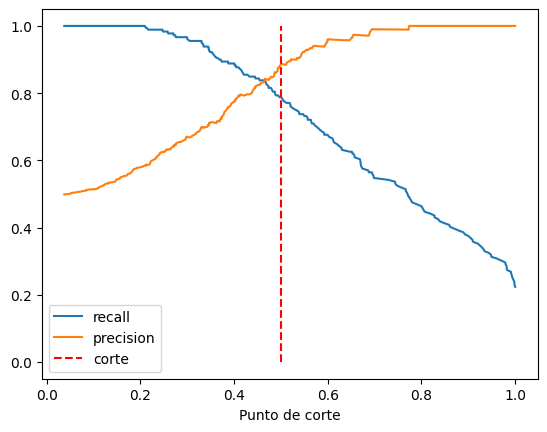

In [133]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

In [134]:
probas_propios = feat_rf.predict_proba(X_propios_features)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.322249
1,respiracion1_ciclo_2.wav,0.756403
2,respiracion1_ciclo_3.wav,0.665650
3,respiracion1_ciclo_4.wav,0.618451
4,respiracion1_ciclo_5.wav,0.787185
5,respiracion1_ciclo_6.wav,0.517262
6,respiracion1_ciclo_7.wav,0.527340
7,respiracion2_ciclo_1.wav,0.808435
8,respiracion2_ciclo_2.wav,0.775083
9,respiracion2_ciclo_3.wav,0.636210


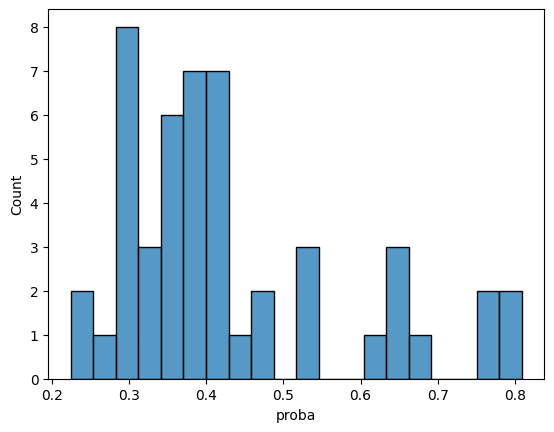

In [135]:
sns.histplot(df_probas, x='proba', bins=20);